In [1]:
"""
scRNA-seq Label Transfer Script
================================
Transfers cell type labels from a reference dataset to a query dataset
using Seurat-style anchor-based integration via scanpy/scvi or
a k-NN weighted approach with scanorama/harmony embeddings.

Methods supported:
  1. KNN-based (default) - fast, uses PCA + cosine similarity
  2. Harmony-based       - batch-corrected embedding before KNN
  3. Seurat-style        - mutual nearest neighbors (MNN) anchors

Requirements:
    pip install scanpy anndata scikit-learn harmonypy scanorama
"""

import argparse
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import anndata as ad
import os


# ─────────────────────────────────────────────
# I/O helpers
# ─────────────────────────────────────────────

def load_adata(path: str) -> ad.AnnData:
    """Load AnnData from .h5ad, .loom, or 10x directory."""
    if path.endswith(".h5ad"):
        return sc.read_h5ad(path)
    elif path.endswith(".loom"):
        return sc.read_loom(path)
    elif path.endswith(".csv"):
        return sc.read_csv(path).T
    else:
        # Assume 10x Genomics directory
        return sc.read_10x_mtx(path, var_names="gene_symbols", cache=True)


def save_adata(adata: ad.AnnData, path: str):
    adata.write_h5ad(path)
    print(f"  Saved → {path}")


# ─────────────────────────────────────────────
# Preprocessing
# ─────────────────────────────────────────────

def preprocess(adata: ad.AnnData, n_top_genes: int = 2000,
               n_pcs: int = 50, name: str = "") -> ad.AnnData:
    """Standard scanpy preprocessing pipeline."""
    print(f"\n[Preprocess] {name}  shape={adata.shape}")
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)

    # Normalise & log
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # HVG
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="cell_ranger", # _v3",
                                 span=0.3)
    adata.raw = adata  # store raw for DE later

    adata = adata[:, adata.var.highly_variable].copy()

    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")

    print(f"  → {adata.shape[0]} cells  |  {adata.shape[1]} HVGs  |  {n_pcs} PCs")
    return adata


# ─────────────────────────────────────────────
# Label transfer methods
# ─────────────────────────────────────────────

def find_common_genes(ref: ad.AnnData, query: ad.AnnData):
    common = list(set(ref.var_names) & set(query.var_names))
    print(f"  Common genes: {len(common)}")
    if len(common) < 100:
        raise ValueError("Too few common genes – check gene naming conventions.")
    return ref[:, common].copy(), query[:, common].copy()


# ── Method 1: KNN on shared PCA ──────────────

def transfer_knn(ref: ad.AnnData, query: ad.AnnData,
                 label_key: str, k: int = 15,
                 n_pcs: int = 30) -> pd.Series:
    """
    Simple KNN label transfer in a shared PCA space.
    Both datasets are concatenated → joint PCA → split back.
    """
    print("\n[Method: KNN] building shared PCA embedding …")

    ref2, query2 = find_common_genes(ref, query)

    # Concatenate for joint PCA
    ref2.obs["_split"] = "reference"
    query2.obs["_split"] = "query"
    combined = ad.concat([ref2, query2], label="_batch",
                         keys=["ref", "query"], join="inner")

    sc.pp.scale(combined, max_value=10)
    sc.tl.pca(combined, n_comps=n_pcs, svd_solver="arpack")

    ref_idx  = combined.obs["_split"] == "reference"
    query_idx = combined.obs["_split"] == "query"

    X_ref   = combined[ref_idx].obsm["X_pca"]
    X_query = combined[query_idx].obsm["X_pca"]
    y_ref   = ref.obs[label_key].values

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine",
                                weights="distance", n_jobs=-1)
    knn.fit(X_ref, y_ref)

    predicted = knn.predict(X_query)
    proba     = knn.predict_proba(X_query)
    confidence = proba.max(axis=1)

    labels = pd.Series(predicted, index=query.obs_names, name="predicted_label")
    conf   = pd.Series(confidence, index=query.obs_names, name="prediction_score")
    return labels, conf, knn.classes_


# ── Method 2: Harmony-corrected KNN ──────────

def transfer_harmony(ref: ad.AnnData, query: ad.AnnData,
                     label_key: str, k: int = 15,
                     n_pcs: int = 30) -> pd.Series:
    """KNN after Harmony batch correction."""
    try:
        import harmonypy as hm
    except ImportError:
        raise ImportError("Install harmonypy:  pip install harmonypy")

    print("\n[Method: Harmony] correcting batch effect …")

    ref2, query2 = find_common_genes(ref, query)
    ref2.obs["_split"] = "reference"
    query2.obs["_split"] = "query"
    combined = ad.concat([ref2, query2], label="_batch",
                         keys=["ref", "query"], join="inner")

    sc.pp.scale(combined, max_value=10)
    sc.tl.pca(combined, n_comps=n_pcs, svd_solver="arpack")

    ho = hm.run_harmony(combined.obsm["X_pca"],
                        combined.obs, "_batch",
                        max_iter_harmony=20, random_state=42)
    combined.obsm["X_harmony"] = ho.Z_corr.T

    ref_idx   = combined.obs["_split"] == "reference"
    query_idx = combined.obs["_split"] == "query"

    X_ref   = combined[ref_idx].obsm["X_harmony"]
    X_query = combined[query_idx].obsm["X_harmony"]
    y_ref   = ref.obs[label_key].values

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine",
                                weights="distance", n_jobs=-1)
    knn.fit(X_ref, y_ref)

    predicted  = knn.predict(X_query)
    confidence = knn.predict_proba(X_query).max(axis=1)

    labels = pd.Series(predicted, index=query.obs_names, name="predicted_label")
    conf   = pd.Series(confidence, index=query.obs_names, name="prediction_score")
    return labels, conf, knn.classes_


# ── Method 3: MNN anchors (Seurat-like) ──────

def transfer_mnn(ref: ad.AnnData, query: ad.AnnData,
                 label_key: str, k: int = 5,
                 k_weight: int = 100, n_pcs: int = 30) -> pd.Series:
    """
    Mutual Nearest Neighbor anchor-based label transfer
    (simplified Seurat TransferData logic in Python).
    """
    print("\n[Method: MNN Anchors] finding mutual nearest neighbors …")

    ref2, query2 = find_common_genes(ref, query)
    sc.pp.scale(ref2,   max_value=10)
    sc.pp.scale(query2, max_value=10)
    sc.tl.pca(ref2,   n_comps=n_pcs, svd_solver="arpack")
    sc.tl.pca(query2, n_comps=n_pcs, svd_solver="arpack")

    from sklearn.neighbors import NearestNeighbors

    # Build KNN graphs
    nn_ref   = NearestNeighbors(n_neighbors=k, metric="cosine").fit(ref2.obsm["X_pca"])
    nn_query = NearestNeighbors(n_neighbors=k, metric="cosine").fit(query2.obsm["X_pca"])

    # ref → query neighbours
    dist_rq, idx_rq = nn_query.kneighbors(ref2.obsm["X_pca"])
    # query → ref neighbours
    dist_qr, idx_qr = nn_ref.kneighbors(query2.obsm["X_pca"])

    # Find mutual pairs (anchors)
    anchors = []
    for r_i, (q_neighbors, _) in enumerate(zip(idx_rq, dist_rq)):
        for q_j in q_neighbors:
            if r_i in idx_qr[q_j]:
                anchors.append((r_i, q_j))

    print(f"  Found {len(anchors)} MNN anchors")

    if len(anchors) < 10:
        print("  ⚠  Very few anchors – falling back to KNN method")
        return transfer_knn(ref, query, label_key, k=k_weight, n_pcs=n_pcs)

    # Weighted label transfer from anchors
    nn_anchors = NearestNeighbors(n_neighbors=min(k_weight, len(anchors)),
                                  metric="cosine")
    anchor_ref_pcs = ref2.obsm["X_pca"][[a[0] for a in anchors]]
    nn_anchors.fit(anchor_ref_pcs)

    dists, idxs = nn_anchors.kneighbors(query2.obsm["X_pca"])
    weights = np.exp(-dists)          # softmax-style weighting
    weights /= weights.sum(axis=1, keepdims=True)

    anchor_labels = np.array([ref.obs[label_key].iloc[anchors[i][0]] for i in range(len(anchors))])
    le = LabelEncoder().fit(anchor_labels)
    anchor_codes = le.transform(anchor_labels)

    # Weighted vote
    predicted, confidence = [], []
    for w, idx in zip(weights, idxs):
        vote = np.zeros(len(le.classes_))
        for wi, ai in zip(w, idx):
            vote[anchor_codes[ai]] += wi
        predicted.append(le.classes_[vote.argmax()])
        confidence.append(vote.max())

    labels = pd.Series(predicted,  index=query.obs_names, name="predicted_label")
    conf   = pd.Series(confidence, index=query.obs_names, name="prediction_score")
    return labels, conf, le.classes_


# ─────────────────────────────────────────────
# Post-processing & output
# ─────────────────────────────────────────────

def add_predictions_to_query(query: ad.AnnData,
                             labels: pd.Series,
                             conf: pd.Series,
                             tag: str = "") -> ad.AnnData:
    query.obs[f"predicted_label_{tag}"]  = labels.values
    query.obs[f"prediction_score_{tag}"] = conf.values
    query.obs[f"high_confidence_{tag}"]  = conf.values >= 0.5
    return query


def print_summary(query: ad.AnnData, label_key: str = None):
    print("\n── Label transfer summary ──────────────────")
    vc = query.obs["predicted_label"].value_counts()
    print(vc.to_string())

    if label_key and label_key in query.obs.columns:
        print("\n── Classification report (ground truth vs predicted) ──")
        print(classification_report(query.obs[label_key],
                                    query.obs["predicted_label"],
                                    zero_division=0))

    mean_conf = query.obs["prediction_score"].mean()
    pct_high  = (query.obs["high_confidence"]).mean() * 100
    print(f"\n  Mean confidence score : {mean_conf:.3f}")
    print(f"  High-confidence cells : {pct_high:.1f}%")


def export_labels_csv(query: ad.AnnData, out_csv: str):
    df = query.obs[["predicted_label", "prediction_score", "high_confidence"]].copy()
    df.to_csv(out_csv)
    print(f"  Labels exported → {out_csv}")


# ─────────────────────────────────────────────
# Programmatic API (import as module)
# ─────────────────────────────────────────────

def transfer_labels(ref: ad.AnnData,
                    query: ad.AnnData,
                    label_key: str,
                    method: str = "knn",
                    k: int = 15,
                    n_pcs: int = 30,
                    n_hvg: int = 2000) -> ad.AnnData:
    """
    Convenience function for use in notebooks / pipelines.

    Example
    -------
    >>> from label_transfer_scrna import transfer_labels
    >>> query = transfer_labels("ref.h5ad", "query.h5ad", label_key="cell_type")
    >>> query.obs[["predicted_label", "prediction_score"]].head()
    """
    # ref   = load_adata(ref_path)
    # query = load_adata(query_path)

    # ref   = preprocess(ref,   n_top_genes=n_hvg, n_pcs=n_pcs, name="reference")
    # query = preprocess(query, n_top_genes=n_hvg, n_pcs=n_pcs, name="query")

    dispatch = {"knn": transfer_knn, "harmony": transfer_harmony, "mnn": transfer_mnn}
    labels, conf, _ = dispatch[method](ref, query, label_key=label_key,
                                       k=k, n_pcs=n_pcs)
    query_updated = add_predictions_to_query(query, labels, conf, tag=method)
     
    return labels, conf, query_updated


In [2]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/'

In [3]:
ITERATORS = [
    ['L23', 'L2/3 IT CTX Glut', 'L2/3'],
    ['L4',  'L4/5 IT CTX Glut', 'L4'],
    ['L5IT',  'L5 IT CTX Glut', 'L5IT'],
    ['L6IT',  'L6 IT CTX Glut', 'L6IT'],
]

In [4]:
ITERATOR = ITERATORS[1]
ITERATOR

['L4', 'L4/5 IT CTX Glut', 'L4']

In [5]:
%%time
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_dev_v1/DevVIS_multiome_snRNA_processed_it_adult.h5ad'
adata = sc.read(f)
adata = adata[adata.obs['subclass_label']==ITERATOR[1]]
adata = adata[adata.obs['age_label'].isin(['P56'])]
adata

CPU times: user 286 ms, sys: 4.07 s, total: 4.35 s
Wall time: 33 s


View of AnnData object with n_obs × n_vars = 5947 × 7100
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [6]:
adata.X.data

array([15,  3,  1, ...,  2,  1, 14], dtype=int32)

In [7]:
%%time
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_multiome_IT.h5ad'
adata2 = sc.read(f)
adata2 = adata2[adata2.obs['Subclass']==ITERATOR[2]].copy()
adata2 = adata2[adata2.obs['Age'].isin(['P21', 'P21DR'])].copy()
adata2

CPU times: user 4.35 s, sys: 21.7 s, total: 26 s
Wall time: 1min 44s


AnnData object with n_obs × n_vars = 5931 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time'
    var: 'feature_types'
    layers: 'norm'

In [8]:
%%time
print(adata2.X.data)

[23.  2. 15. ...  1.  4.  1.]
CPU times: user 88 µs, sys: 271 µs, total: 359 µs
Wall time: 332 µs


In [9]:
ref = adata.copy()
query = adata2.copy()
methods =['knn', 'harmony', 'mnn']
label_key = 'cluster_label'
ref.obs[label_key].unique()

['100_L4/5 IT CTX Glut_6', '82_L4/5 IT CTX Glut_2', '68_L4/5 IT CTX Glut_1', '73_L4/5 IT CTX Glut_1', '101_L4/5 IT CTX Glut_6']
Categories (5, object): ['68_L4/5 IT CTX Glut_1', '73_L4/5 IT CTX Glut_1', '82_L4/5 IT CTX Glut_2', '100_L4/5 IT CTX Glut_6', '101_L4/5 IT CTX Glut_6']

In [10]:
n_hvg = 3000
n_pcs = 30

ref   = preprocess(ref,   n_top_genes=n_hvg, n_pcs=n_pcs, name="reference")
query = preprocess(query, n_top_genes=n_hvg, n_pcs=n_pcs, name="query")


[Preprocess] reference  shape=(5947, 7100)
  → 5947 cells  |  3000 HVGs  |  30 PCs

[Preprocess] query  shape=(5931, 16567)
  → 5931 cells  |  3000 HVGs  |  30 PCs


In [11]:
# palette = {f'C{i}': lbl for i, lbl in enumerate(ref[label_key].unique())}
# palette
hue_order = np.sort(ref.obs[label_key].unique())
hue_order
                                                

array(['100_L4/5 IT CTX Glut_6', '101_L4/5 IT CTX Glut_6',
       '68_L4/5 IT CTX Glut_1', '73_L4/5 IT CTX Glut_1',
       '82_L4/5 IT CTX Glut_2'], dtype=object)


[Method: KNN] building shared PCA embedding …
  Common genes: 1402


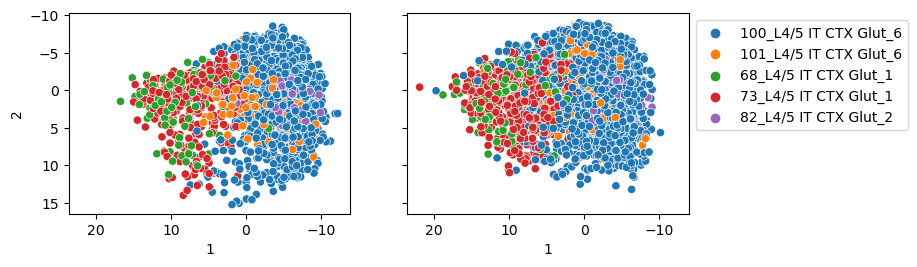

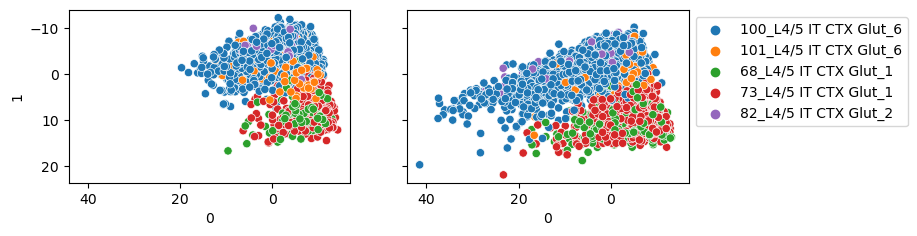


[Method: Harmony] correcting batch effect …
  Common genes: 1402


2026-03-05 15:15:50,151 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-05 15:15:53,785 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-05 15:15:53,825 - harmonypy - INFO - Iteration 1 of 20
2026-03-05 15:15:55,737 - harmonypy - INFO - Iteration 2 of 20
2026-03-05 15:15:57,653 - harmonypy - INFO - Iteration 3 of 20
2026-03-05 15:15:59,565 - harmonypy - INFO - Iteration 4 of 20
2026-03-05 15:16:01,475 - harmonypy - INFO - Iteration 5 of 20
2026-03-05 15:16:03,401 - harmonypy - INFO - Iteration 6 of 20
2026-03-05 15:16:05,308 - harmonypy - INFO - Iteration 7 of 20
2026-03-05 15:16:07,055 - harmonypy - INFO - Iteration 8 of 20
2026-03-05 15:16:08,710 - harmonypy - INFO - Converged after 8 iterations


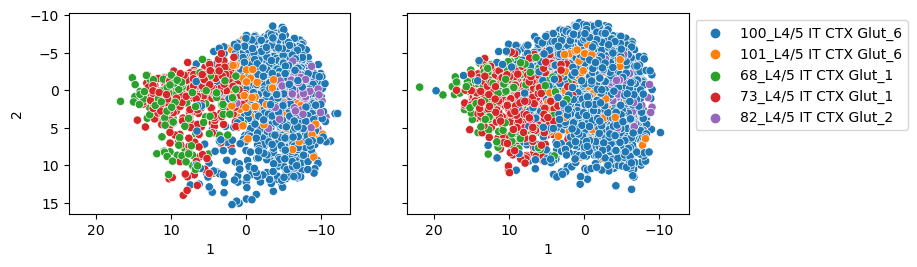

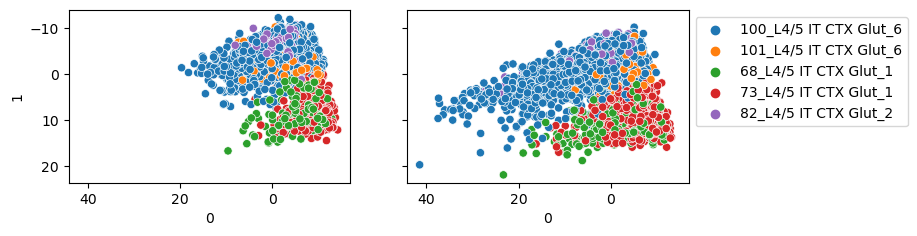


[Method: MNN Anchors] finding mutual nearest neighbors …
  Common genes: 1402
  Found 22756 MNN anchors


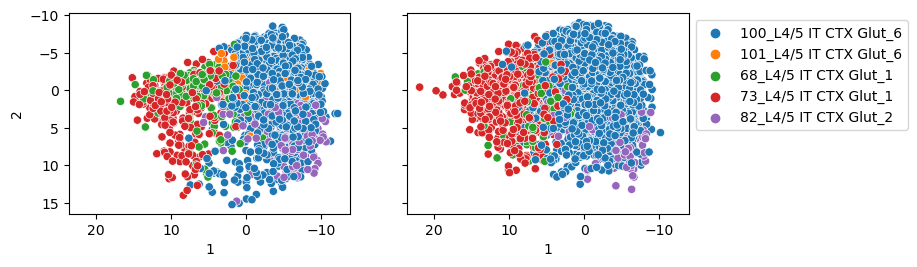

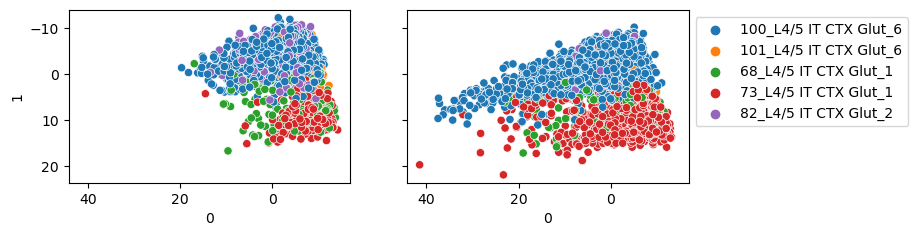

CPU times: user 32.2 s, sys: 5.39 s, total: 37.6 s
Wall time: 38.9 s


In [12]:
%%time

np.random.seed(0)

for method in methods:
    labels, confs, query_labeled = transfer_labels(ref, query, label_key, method=method)
    
    cells = query_labeled.obs.index.values
    res = np.column_stack((cells,labels, confs))
    np.savetxt(os.path.join(ddir, f"{ITERATOR[0]}_labels_gao25_to_yoo25_{method}.csv"), res, 
               fmt="%s",delimiter=",", header="label,conf", comments="")
    
    
    pcs  = query_labeled.obsm['X_pca']
    isnr = query_labeled.obs['Age'].values=='P21'
    labels = query_labeled.obs[f'predicted_label_{method}'].values

    dfviz = pd.DataFrame(pcs[:,:3])
    dfviz['isnr'] = isnr
    dfviz['type'] = labels

    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axs = plt.subplots(1,2,figsize=(2*4,1*4), sharex=True, sharey=True)
    ax = axs[0]
    sns.scatterplot(data=dfviz[isnr], x=1, y=2, hue='type', hue_order=hue_order, legend=False, ax=ax)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_aspect('equal')

    ax = axs[1]
    sns.scatterplot(data=dfviz[~isnr], x=1, y=2, hue='type',hue_order=hue_order, ax=ax)
    ax.set_aspect('equal')
    # ax.invert_xaxis()
    # ax.invert_yaxis()
    ax.legend(bbox_to_anchor=(1,1))
    plt.show()

    fig, axs = plt.subplots(1,2,figsize=(2*4,1*4), sharex=True, sharey=True)
    ax = axs[0]
    sns.scatterplot(data=dfviz[isnr], x=0, y=1, hue='type', hue_order=hue_order, legend=False, ax=ax)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_aspect('equal')

    ax = axs[1]
    sns.scatterplot(data=dfviz[~isnr], x=0, y=1, hue='type', hue_order=hue_order, ax=ax)
    # ax.invert_xaxis()
    # ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1,1))
    plt.show()

In [13]:
query_labeled.obs.columns

Index(['Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes',
       'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample',
       'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt',
       'Doublet?', 'Study', 'Type_leiden', 'time', 'predicted_label_knn',
       'prediction_score_knn', 'high_confidence_knn',
       'predicted_label_harmony', 'prediction_score_harmony',
       'high_confidence_harmony', 'predicted_label_mnn',
       'prediction_score_mnn', 'high_confidence_mnn'],
      dtype='object')

In [14]:
!ls -alhtr $ddir  #/L4_labels_gao25_to_yoo25_knn.csv

total 92G
-rw-r--r--. 1 f7xiesnm zipursky 576M Apr 12  2024 L23_allmultiome_raw.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 1.3G Apr 19  2024 L23_Allraw.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 3.0K May 20  2024 Saumya_P6-21_AC_genes.csv
-rw-r--r--. 1 f7xiesnm zipursky  53M Jun  6  2024 atac_qs_avc_p6to21.txt
-rw-r--r--. 1 f7xiesnm zipursky  54M Jun  6  2024 atac_l2fc_avc_p6to21.txt
-rw-r--r--. 1 f7xiesnm zipursky 2.8M Jun  7  2024 rna_qs_avc_p6to21.txt
-rw-r--r--. 1 f7xiesnm zipursky 2.9M Jun  7  2024 rna_l2fc_avc_p6to21.txt
-rw-r--r--. 1 f7xiesnm zipursky  26G Jun 17  2024 scplus_obj_inter_v2.pkl
-rw-r--r--. 1 f7xiesnm zipursky 3.9G Jun 24  2024 L23_allmultiome_proc_P6toP21_NRDR.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 2.7G Jun 25  2024 L23_allmultiome_proc_P6toP21.h5ad
-rw-r--r--. 1 f7xiesnm zipursky  18G Jan  8  2025 superdupermegaRNA_hasraw.h5ad
drwxr-xr-x. 2 f7xiesnm zipursky 4.0K Jan 14  2025 from_sal
-rw-r--r--. 1 f7xiesnm zipursky  32M Jan 22  2025 DAR_l23abc_qs.npy
-rw-r--r--. 1 f7xiesnm zi